# NLP-Based Quality Feedback Analyzer
## Week 3: Topic Modeling & Named Entity Recognition

This notebook trains a Latent Dirichlet Allocation (LDA) topic model to classify reviews into distinct business categories, runs spaCy Named Entity Recognition (NER) combined with custom keyword extraction to extract products/complaints, and generates visualizations of topic frequencies split by sentiment.

### Tasks Completed:
1. Load sentiment-labeled dataset and merge with cleaned text tokens.
2. Build a Document-Term Matrix (DTM) using `CountVectorizer`.
3. Train an LDA topic model with 6 topics.
4. Manually assign human-readable business labels based on top words.
5. Identify the dominant topic for each review and add a `topic_label` column.
6. Save the trained LDA model and vectorizer to `models/lda_model/`.
7. Run spaCy NER (`en_core_web_sm`) and custom keyword extraction on raw review text to create an `entities` column.
8. Merge all elements into `outputs/extracted_topics.csv`.
9. Generate a topic frequency visualization split by positive vs. negative sentiment and save to `outputs/figures/topic_word_distribution.png`.
10. Generate an interactive pyLDAvis visual and save to `outputs/figures/lda_visualization.html`.

In [1]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Data Ingestion & Merging

We load the sentiment dataset `outputs/labeled_dataset.csv` (2,000 rows) and map it back to `data/processed/reviews_cleaned.csv` to retrieve the `cleaned_text` tokens that were prepared in Week 1.

In [2]:
# Load datasets
df_labeled = pd.read_csv("../outputs/labeled_dataset.csv")
df_cleaned_full = pd.read_csv("../data/processed/reviews_cleaned.csv", usecols=['Text', 'cleaned_text'])

# Merge to bring in cleaned_text tokens based on matching RAW text
df_merged = pd.merge(df_labeled, df_cleaned_full, left_on='review text', right_on='Text', how='left')

# Drop helper columns and fill any missing tokens
df_merged.drop(columns=['Text'], inplace=True, errors='ignore')
df_merged['cleaned_text'] = df_merged['cleaned_text'].fillna("")

print(f"Merged dataset shape: {df_merged.shape}")
df_merged.head(5)

Merged dataset shape: (2000, 7)


,review text,rating,vader_label,distilbert_label,distilbert_confidence,rating_based_truth,cleaned_text
0,I have purchased this for approximately the pa...,5,negative,positive,0.923081,positive,purchased approximately past year truly helped...
1,I just had a big bowl of oatmeal and I'm not s...,5,positive,positive,0.999024,positive,big bowl oatmeal im sick heartburn cramp feel ...
2,"<a href=""http://www.amazon.com/gp/product/B000...",1,positive,negative,0.998917,negative,hrefhttpwwwamazoncomgpproductbcmkpdinew poopfr...
3,Apparently the other reviewer for this product...,5,positive,positive,0.500000,positive,apparently reviewer product underwear wad pric...
4,I have never used better salt. It is better t...,5,negative,positive,0.999471,positive,never used better salt better tasting prettier...


### 2. Document-Term Matrix & LDA Training

We use `CountVectorizer` to construct the DTM from the cleaned tokens and then fit a 6-topic `LatentDirichletAllocation` model.

In [10]:
# Construct Document-Term Matrix
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(df_merged['cleaned_text'])
print(f"DTM shape: {dtm.shape[0]} documents, {dtm.shape[1]} vocabulary size")

# Train LDA Model
lda_model = LatentDirichletAllocation(n_components=6, random_state=42)
lda_model.fit(dtm)

# Print top words
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")

DTM shape: 2000 documents, 6911 vocabulary size
Topic 0: br, protein, sugar, noodle, fat, taste, salt, chocolate, calorie, bar
Topic 1: br, taste, product, tea, oil, like, water, use, sugar, coconut
Topic 2: rice, great, taste, popcorn, br, flavor, good, like, chip, make
Topic 3: product, honey, box, day, order, chocolate, ordered, br, dog, rabbit
Topic 4: br, food, like, product, dog, good, make, great, flavor, cat
Topic 5: coffee, tea, br, cup, like, flavor, box, taste, bean, good


### 3. Assigning Dominant Topic Business Labels

Based on the top words, we manually map the topic indices to descriptive business labels (lowercase snake_case):
- **Topic 0**: `nutritional_profile` (protein, sugar, calorie, bars, noodles)
- **Topic 1**: `beverages_and_liquids` (tea, water, coconut, oil, liquids)
- **Topic 2**: `chips_and_snacks` (rice, popcorn, chips, snacks)
- **Topic 3**: `order_and_delivery` (order, ordered, box, package, shipping)
- **Topic 4**: `pet_food` (dog, cat, pet food)
- **Topic 5**: `coffee_and_tea_pods` (coffee, tea, cup, beans, keurig)

In [4]:
# Define topic mapping dictionary
topic_mapping = {
    0: 'nutritional_profile',
    1: 'beverages_and_liquids',
    2: 'chips_and_snacks',
    3: 'order_and_delivery',
    4: 'pet_food',
    5: 'coffee_and_tea_pods'
}

# Determine the dominant topic for each document
lda_probs = lda_model.transform(dtm)
dominant_topic_indices = np.argmax(lda_probs, axis=1)

# Assign labels
df_merged['topic_label'] = [topic_mapping[idx] for idx in dominant_topic_indices]

# Save model and vectorizer
model_dir = "../models/lda_model/"
os.makedirs(model_dir, exist_ok=True)
joblib.dump(lda_model, os.path.join(model_dir, "lda_model.pkl"))
joblib.dump(vectorizer, os.path.join(model_dir, "count_vectorizer.pkl"))

print("Trained LDA model and vectorizer saved successfully to models/lda_model/")
print("\nTopic counts:")
print(df_merged['topic_label'].value_counts())

Trained LDA model and vectorizer saved successfully to models/lda_model/

Topic counts:
topic_label
pet_food                 728
beverages_and_liquids    471
coffee_and_tea_pods      295
order_and_delivery       231
chips_and_snacks         141
nutritional_profile      134
Name: count, dtype: int64


### 4. Named Entity Recognition (NER) & Custom Keywords Extraction

We run spaCy's `en_core_web_sm` model on the **RAW, unprocessed review text** to extract `ORG` and `PRODUCT` entities. We also supplement this with matching custom feedback words like complaints (`broken`, `damaged`, `leaked`, `stale`) and features (`delicious`, `fresh`, `perfect`).

In [5]:
# Load spaCy Small English Model
nlp = spacy.load("en_core_web_sm")

feedback_keywords = {
    # complaints
    'broken', 'damaged', 'leaked', 'moldy', 'stale', 'expired', 'slow', 'missing', 'worst', 'waste',
    # features/positive
    'fresh', 'delicious', 'organic', 'sweet', 'perfect', 'favorite', 'excellent'
}

def extract_entities_and_keywords(text):
    if not isinstance(text, str):
        return "none"
        
    doc = nlp(text)
    
    # Extract spaCy ORG and PRODUCT labels
    extracted = set()
    for ent in doc.ents:
        if ent.label_ in ['ORG', 'PRODUCT']:
            clean_ent = ent.text.strip().lower()
            if len(clean_ent) > 1:
                # Strip leading/trailing formatting
                clean_ent = re.sub(r'^\W+|\W+$', '', clean_ent)
                if clean_ent:
                    extracted.add(clean_ent)
                    
    # Match custom quality keywords
    words = [w.strip(".,!?\"'()").lower() for w in text.split()]
    for w in words:
        if w in feedback_keywords:
            extracted.add(w)
            
    # Return as comma-separated string
    return ", ".join(sorted(extracted)) if extracted else "none"

# Run NER and custom keywords matching on RAW review text
df_merged['entities'] = [extract_entities_and_keywords(t) for t in tqdm(df_merged['review text'], desc="Extracting Entities")]

print("\nSample extracted entities and keywords:")
df_merged[['review text', 'entities']].head(5)

Extracting Entities: 100%|██████████| 2000/2000 [00:44<00:00, 44.92it/s]


Sample extracted entities and keywords:


,review text,entities
0,I have purchased this for approximately the pa...,keep
1,I just had a big bowl of oatmeal and I'm not s...,"delicious, rolled oats"
2,"<a href=""http://www.amazon.com/gp/product/B000...",none
3,Apparently the other reviewer for this product...,"amazon, red mill, southerner, yankee"
4,I have never used better salt. It is better t...,none


### 5. Final Dataset Merger & Export

We compile the columns: `review text`, `rating`, `vader_label`, `distilbert_label`, `distilbert_confidence`, `topic_label`, `entities` and save to `outputs/extracted_topics.csv`.

In [6]:
# Extract specific columns
export_cols = [
    'review text', 
    'rating', 
    'vader_label', 
    'distilbert_label', 
    'distilbert_confidence', 
    'topic_label', 
    'entities'
]
df_final = df_merged[export_cols].copy()

# Save final CSV
output_csv = "../outputs/extracted_topics.csv"
os.makedirs(os.path.dirname(output_csv), exist_ok=True)
df_final.to_csv(output_csv, index=False)

print(f"Saved final dataset to {output_csv} with {len(df_final)} rows.")

Saved final dataset to ../outputs/extracted_topics.csv with 2000 rows.


### 6. Visualizations

We generate two visualizations:
1. A static bar chart of topic frequencies, split by sentiment (rating-based ground truth) and save it to `outputs/figures/topic_word_distribution.png`.
2. An interactive pyLDAvis HTML panel saved to `outputs/figures/lda_visualization.html`.

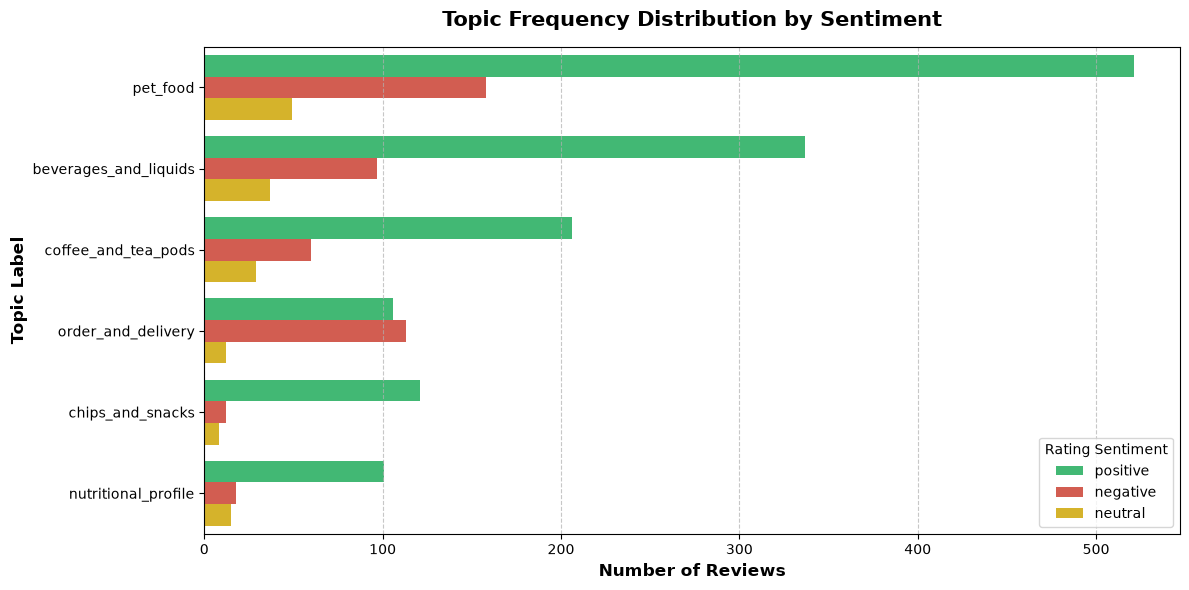

Topic frequency plot saved to ../outputs/figures/topic_word_distribution.png


In [7]:
# Generate topic-sentiment counts
plt.figure(figsize=(12, 6))

# Define positive and negative sentiment split using the rating ground truth
# (combining neutral into negative/positive or plotting all three)
# Let's plot positive vs negative (ignoring neutral or plotting it)
# We will use rating_based_truth (positive / negative / neutral)
sns.countplot(
    data=df_merged, 
    y='topic_label', 
    hue='rating_based_truth', 
    order=df_merged['topic_label'].value_counts().index,
    palette={'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#f1c40f'}
)

plt.title('Topic Frequency Distribution by Sentiment', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Number of Reviews', fontsize=12, fontweight='bold')
plt.ylabel('Topic Label', fontsize=12, fontweight='bold')
plt.legend(title='Rating Sentiment', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
fig_out_path = "../outputs/figures/topic_word_distribution.png"
os.makedirs(os.path.dirname(fig_out_path), exist_ok=True)
plt.savefig(fig_out_path, dpi=150)
plt.show()
print(f"Topic frequency plot saved to {fig_out_path}")

In [8]:
# Interactive pyLDAvis Visualization
try:
    import pyLDAvis
    import pyLDAvis.lda_model
    
    # Prepare pyLDAvis panel
    vis_data = pyLDAvis.lda_model.prepare(lda_model, dtm, vectorizer, mds='tsne')
    
    # Save as HTML
    html_out_path = "../outputs/figures/lda_visualization.html"
    pyLDAvis.save_html(vis_data, html_out_path)
    print(f"pyLDAvis interactive dashboard successfully saved to {html_out_path}")
except Exception as e:
    print(f"Warning: pyLDAvis failed to generate visualization due to version/dependency mismatch: {e}")

pyLDAvis interactive dashboard successfully saved to ../outputs/figures/lda_visualization.html
